# Análisis Exploratorio: Panel Distrital Final

Panel de 1,891 distritos peruanos con datos de anemia, gasto en salud y características geográficas (2020–2026).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/clean/merged/panel_distrital_final.csv')
print(f'Forma: {df.shape}  |  Distritos: {df["ubigeo"].nunique()}  |  Años: {sorted(df["anio"].unique())}')

Forma: (13148, 36)  |  Distritos: 1891  |  Años: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 1. Vista general del panel

In [2]:
df.describe(include='all').T[['count','mean','std','min','max']].round(2)

,count,mean,std,min,max
ubigeo,13148.0,106857.263766,67168.990576,10101.0,250401.0
anio,13148.0,2023.013158,1.991897,2020.0,2026.0
ninos_evaluados,13029.0,304.719702,802.802632,0.0,20870.0
ninos_con_anemia,13029.0,62.692302,156.255591,0.0,3441.0
ninos_sin_anemia,13029.0,242.0274,674.147804,0.0,18511.0
prevalencia_anemia,12987.0,0.267733,0.226373,0.0,1.0
gasto_total,9452.0,118892999.052643,1572745929.356745,122563.2,71416946017.160004
gasto_anemia_pan,9452.0,393429.708193,5473743.476975,0.0,436443094.04
personal_total,7336.0,99.41235,304.328452,0.0,7254.0
programa_anemia,7526.0,0.507441,0.499978,0.0,1.0


In [3]:
# Cobertura: qué porcentaje de ubigeos tiene datos por año
cobertura = df.groupby('anio').agg(
    distritos=('ubigeo', 'nunique'),
    con_gasto=('gasto_total', lambda x: x.notna().sum()),
    con_anemia=('prevalencia_anemia', lambda x: x.notna().sum())
).assign(
    pct_gasto=lambda d: (d.con_gasto / d.distritos * 100).round(1),
    pct_anemia=lambda d: (d.con_anemia / d.distritos * 100).round(1)
)
print(cobertura)

      distritos  con_gasto  con_anemia  pct_gasto  pct_anemia
anio                                                         
2020       1820          0        1808        0.0        99.3
2021       1889       1889        1835      100.0        97.1
2022       1890       1890        1837      100.0        97.2
2023       1891       1891        1868      100.0        98.8
2024       1891       1891        1878      100.0        99.3
2025       1891       1891        1885      100.0        99.7
2026       1876          0        1876        0.0       100.0


## 2. Tendencia nacional de prevalencia de anemia

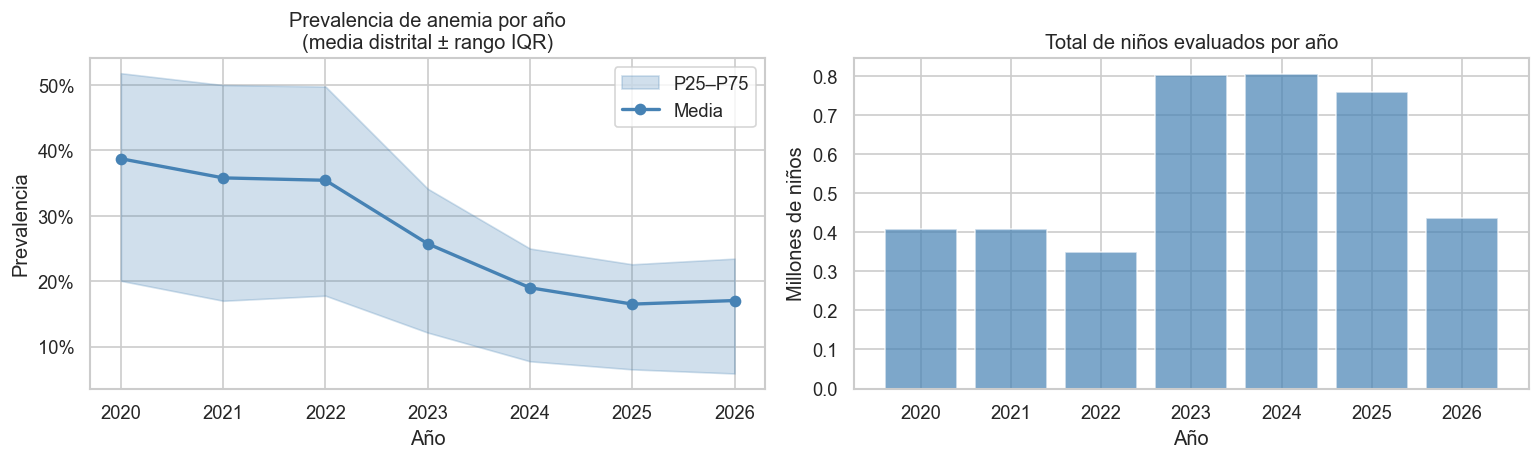

In [4]:
anio_agg = df.groupby('anio').agg(
    prev_media=('prevalencia_anemia', 'mean'),
    prev_p25=('prevalencia_anemia', lambda x: x.quantile(0.25)),
    prev_p75=('prevalencia_anemia', lambda x: x.quantile(0.75)),
    ninos_total=('ninos_evaluados', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Prevalencia media + rango intercuartílico
ax = axes[0]
ax.fill_between(anio_agg.anio, anio_agg.prev_p25, anio_agg.prev_p75,
                alpha=0.25, color='steelblue', label='P25–P75')
ax.plot(anio_agg.anio, anio_agg.prev_media, marker='o', color='steelblue',
        linewidth=2, label='Media')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Prevalencia de anemia por año\n(media distrital ± rango IQR)')
ax.set_xlabel('Año')
ax.set_ylabel('Prevalencia')
ax.legend()

# Niños evaluados
ax2 = axes[1]
ax2.bar(anio_agg.anio, anio_agg.ninos_total / 1e6, color='steelblue', alpha=0.7)
ax2.set_title('Total de niños evaluados por año')
ax2.set_xlabel('Año')
ax2.set_ylabel('Millones de niños')

plt.tight_layout()
plt.savefig('fig_tendencia_nacional.png', bbox_inches='tight')
plt.show()

## 3. Prevalencia por macrorregión

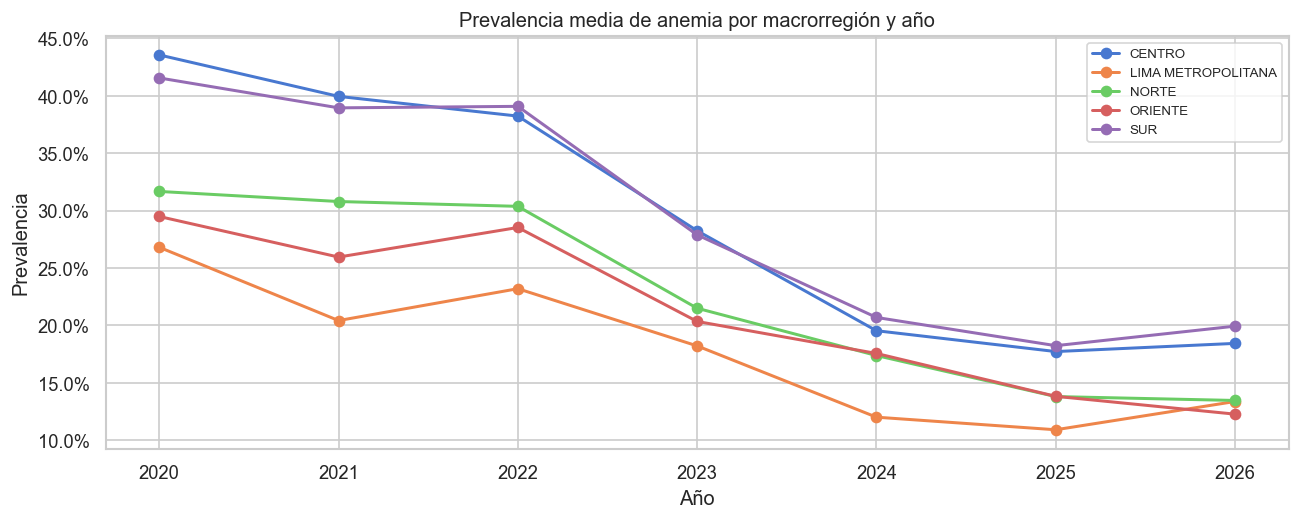

In [5]:
macro_anio = df.groupby(['anio', 'macroregion_inei'])['prevalencia_anemia'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
for macro, grp in macro_anio.groupby('macroregion_inei'):
    ax.plot(grp.anio, grp.prevalencia_anemia, marker='o', linewidth=1.8, label=macro)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Prevalencia media de anemia por macrorregión y año')
ax.set_xlabel('Año')
ax.set_ylabel('Prevalencia')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('fig_macroregion.png', bbox_inches='tight')
plt.show()

## 4. Distribución de la prevalencia (2023)

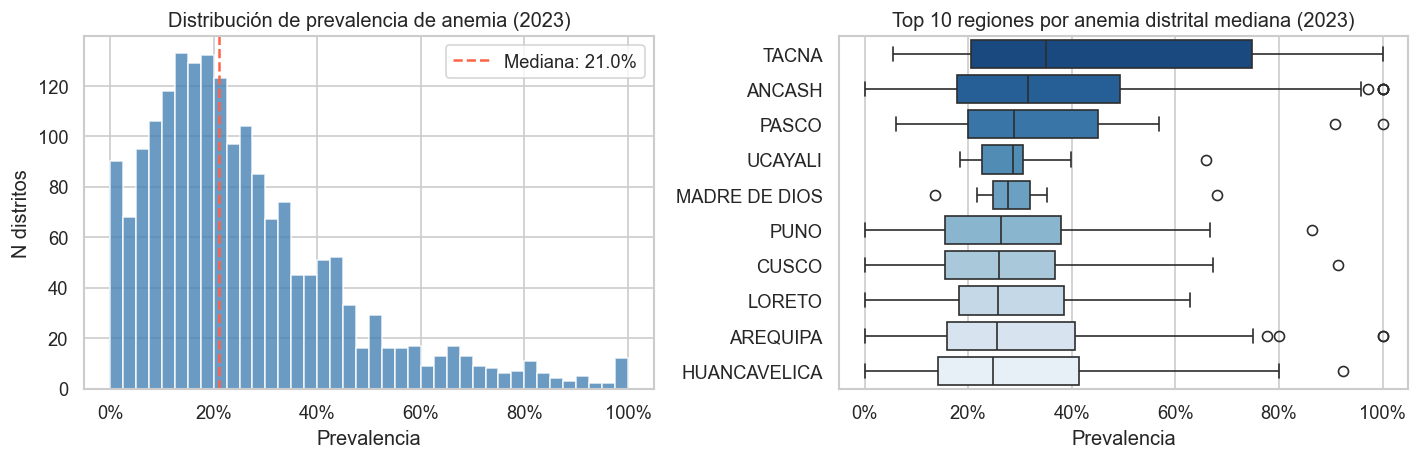

In [6]:
df23 = df[df.anio == 2023].dropna(subset=['prevalencia_anemia'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df23.prevalencia_anemia, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df23.prevalencia_anemia.median(), color='tomato', linestyle='--', label=f'Mediana: {df23.prevalencia_anemia.median():.1%}')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_title('Distribución de prevalencia de anemia (2023)')
axes[0].set_xlabel('Prevalencia')
axes[0].set_ylabel('N distritos')
axes[0].legend()

# Boxplot por región (top 10 con mayor anemia)
top10 = df23.groupby('region')['prevalencia_anemia'].median().nlargest(10).index
df23_top = df23[df23.region.isin(top10)]
order = df23_top.groupby('region')['prevalencia_anemia'].median().sort_values(ascending=False).index
sns.boxplot(data=df23_top, y='region', x='prevalencia_anemia', order=order,
            ax=axes[1], palette='Blues_r')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Top 10 regiones por anemia distrital mediana (2023)')
axes[1].set_xlabel('Prevalencia')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig_distribucion_2023.png', bbox_inches='tight')
plt.show()

## 5. Relación gasto en anemia vs. prevalencia

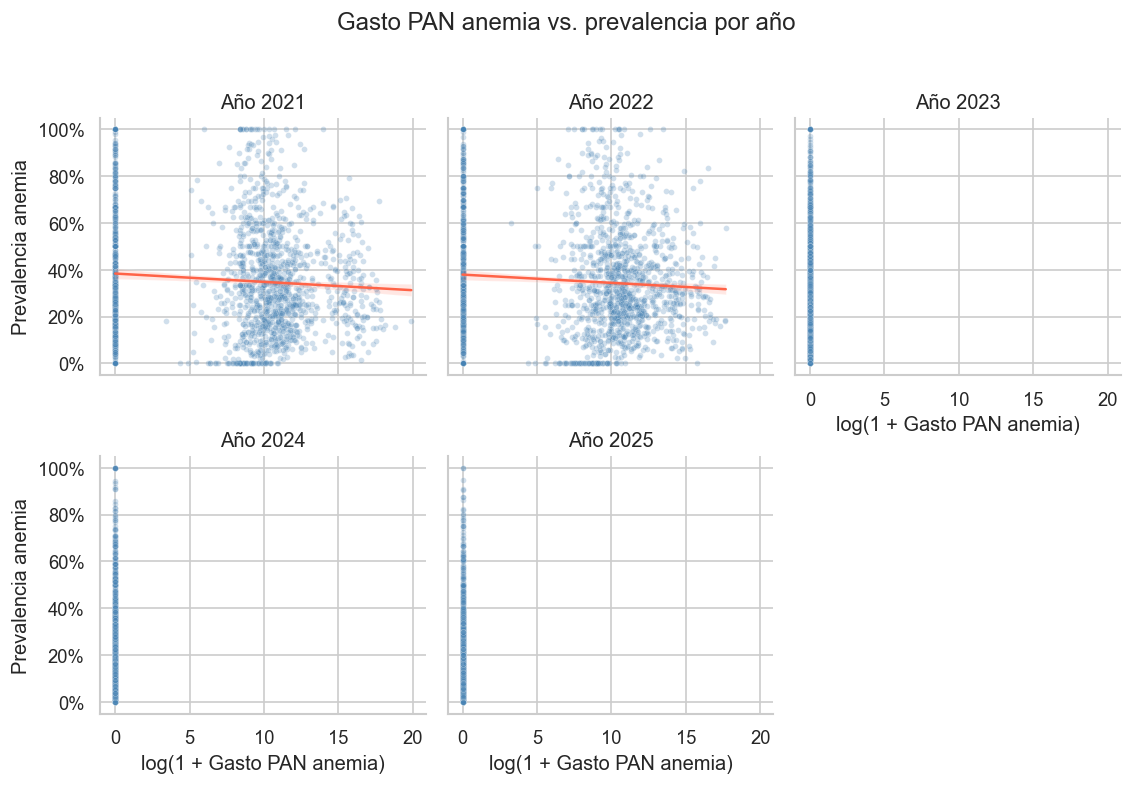

In [7]:
df_gasto = df[(df.anio >= 2021) & df.gasto_anemia_pan.notna() & df.prevalencia_anemia.notna()].copy()
df_gasto['log_gasto'] = np.log1p(df_gasto.gasto_anemia_pan)

g = sns.FacetGrid(df_gasto, col='anio', col_wrap=3, height=3.2, sharey=True, sharex=True)
g.map_dataframe(sns.scatterplot, x='log_gasto', y='prevalencia_anemia',
                alpha=0.25, s=12, color='steelblue')
g.map_dataframe(sns.regplot, x='log_gasto', y='prevalencia_anemia',
                scatter=False, color='tomato', line_kws={'linewidth': 1.5})
g.set_axis_labels('log(1 + Gasto PAN anemia)', 'Prevalencia anemia')
g.set_titles('Año {col_name}')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
g.figure.suptitle('Gasto PAN anemia vs. prevalencia por año', y=1.02)
plt.tight_layout()
plt.savefig('fig_gasto_vs_anemia.png', bbox_inches='tight')
plt.show()

## 6. Correlaciones con la prevalencia de anemia

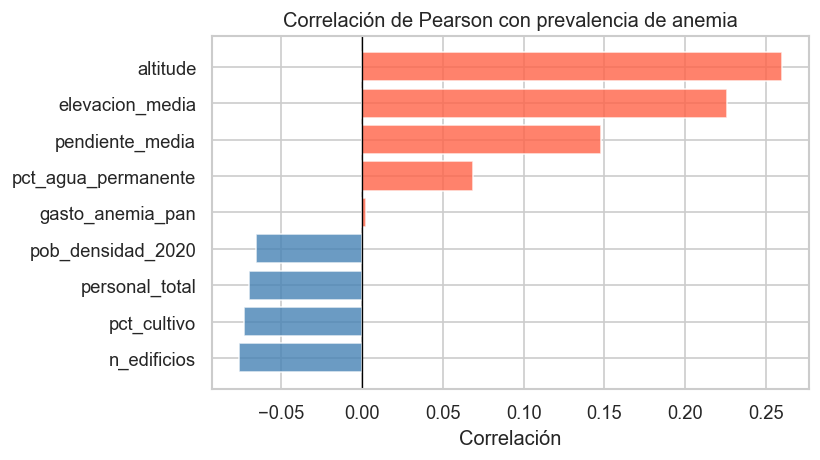

                     prevalencia_anemia
n_edificios                      -0.076
pct_cultivo                      -0.073
personal_total                   -0.070
pob_densidad_2020                -0.066
gasto_anemia_pan                  0.003
pct_agua_permanente               0.069
pendiente_media                   0.148
elevacion_media                   0.226
altitude                          0.260


In [8]:
numericas = [
    'prevalencia_anemia', 'gasto_anemia_pan', 'personal_total',
    'altitude', 'pob_densidad_2020', 'elevacion_media', 'pendiente_media',
    'pct_cultivo', 'pct_agua_permanente', 'n_edificios'
]

corr = df[numericas].corr()[['prevalencia_anemia']].drop('prevalencia_anemia').sort_values('prevalencia_anemia')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr.prevalencia_anemia]
ax.barh(corr.index, corr.prevalencia_anemia, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson con prevalencia de anemia')
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.savefig('fig_correlaciones.png', bbox_inches='tight')
plt.show()

print(corr.round(3))

## 7. Resumen estadístico por año

In [9]:
resumen = df.groupby('anio').agg(
    n_distritos=('ubigeo', 'nunique'),
    prev_media=('prevalencia_anemia', 'mean'),
    prev_mediana=('prevalencia_anemia', 'median'),
    prev_p10=('prevalencia_anemia', lambda x: x.quantile(0.1)),
    prev_p90=('prevalencia_anemia', lambda x: x.quantile(0.9)),
    gasto_pan_media=('gasto_anemia_pan', 'mean'),
    ninos_total=('ninos_evaluados', 'sum')
).round(3)

resumen.style.format({
    'prev_media': '{:.1%}', 'prev_mediana': '{:.1%}',
    'prev_p10': '{:.1%}', 'prev_p90': '{:.1%}',
    'gasto_pan_media': 'S/ {:,.0f}',
    'ninos_total': '{:,.0f}'
})

,n_distritos,prev_media,prev_mediana,prev_p10,prev_p90,gasto_pan_media,ninos_total
anio,,,,,,,
2020,1820,38.7%,34.6%,8.5%,76.8%,S/ nan,"407,510"
2021,1889,35.8%,31.8%,6.1%,73.3%,"S/ 1,432,394","408,908"
2022,1890,35.4%,31.1%,5.9%,73.4%,"S/ 535,929","349,835"
2023,1891,25.7%,21.0%,5.7%,50.4%,S/ 0,"802,247"
2024,1891,19.0%,14.6%,3.1%,39.2%,S/ 0,"805,028"
2025,1891,16.5%,12.8%,2.0%,34.1%,S/ 0,"759,314"
2026,1876,17.0%,13.0%,0.0%,34.8%,S/ nan,"437,351"
